In [4]:
#### trying to make things more reproducible
import numpy as np
import random
import os
import torch

# 1. Set environment variables
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["NUMBA_CPU_NAME"] = "generic"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set Seeds
SEED = 0
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True, warn_only=True) 

from pathlib import Path
import decoupler as dc
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scvi

import sys

sys.path.extend(["../../scripts","../../scripts/xenium"])
import readwrite
from preprocessing import subsample, get_gene_stats
from integration import transfer_labels_knn, evaluate_label_transfer, find_neighbor_same_donor

cfg = readwrite.config()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/__init__.py:44: F

## Params

In [5]:
condition_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'condition_palette.csv',index_col=0).iloc[:,0].to_dict()
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0).iloc[:,0].to_dict()
gene_sets_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'gene_sets_palette.csv',index_col=0).iloc[:,0].to_dict()
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0).iloc[:,0].to_dict()

palettes = {
    "condition": condition_palette,
    "donor_corrected": donor_palette,
    "gene_sets": gene_sets_palette,
    "cell_type": cell_type_palette,
    "leiden_0.6_named": gene_sets_palette,
}


xenium_dir = Path(cfg["xenium_processed_dir"])
xenium_count_correction_dir = Path(cfg["xenium_count_correction_dir"])
xenium_std_seurat_analysis_dir = Path(cfg["xenium_std_seurat_analysis_dir"])
xenium_cell_type_annotation_dir = Path(cfg["xenium_cell_type_annotation_dir"])
results_dir = Path(cfg["results_dir"])

# input params
cellcharter_dir = "cellcharter_cohort"
correction_method = "raw"
segmentation = "proseg_expected"
condition = "all"
panel = "all"
normalisation = "lognorm"
reference = "GEO_GSE178341"
method = "rctd_class_aware"
level = "Level1"
xenium_levels = ["segmentation", "condition", "panel", "donor", "sample"]
name_malignant = "Epi"

# qc params
min_n_counts = 20

# fixed params
BATCH_KEY = "dataset_id"
SPATIAL_KEY = "spatial"

segmentations_filter = [segmentation]
conditions_filter = [condition] if condition != "all" else None
panels_filter = [panel] if panel != "all" else None

leiden_names = {}
leiden_names[0.6] = {
    0:	"Cycling_high",
    1:	"Transit-amplifying",
    2:	"Stem-like",
    3:	"Chemokine_EMT",
    4:	"Goblet_Inflammatory",
    5:	"Goblet_MUC",
    6:	"Stress_Inflammatory"
    }

In [6]:
integration_method = 'bbknn'
run = 12

print(integration_method,run)

bbknn 12


# Read results

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_o

Error processing [Errno 2] No such file or directory: '/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/proseg/CRC/hImmune_v1_mm/169V/output-XETG00059__0032822__169V__20250811__161841/raw_results/experiment.xenium'


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: Implic

Error processing [Errno 2] No such file or directory: '/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/proseg/CRC_PDO/hImmune_v1_dapi/169V/output-XETG00059__0003881__169V_not_1JSK_20250505__170804/raw_results/experiment.xenium'


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:831: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  r

dict_keys([('proseg_expected', 'CRC', 'hImmune_v1_mm', '03FO', 'HCC_output-XETG00209__0003786__03F0__20250503__073331'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '077I', 'output-XETG00059__0032822__O77I__20250811__161841'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '07WM', 'output-XETG00059__0033408__O7WM__20250910__132524'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '12WP', 'output-XETG00059__0053261__12WP__20250306__164822'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '131N', 'HCC_output-XETG00209__0003786__131N__20250503__073331'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '14V5', 'output-XETG00059__0053259__14V5__20250306__164822'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '19II', 'output-XETG00059__0053259__19II__20250306__164822'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '1CFW', 'output-XETG00059__0053259__1CFW__20250306__164822'), ('proseg_expected', 'CRC', 'hImmune_v1_mm', '1CI5', 'HCC_output-XETG00209__0003786__1CI5__20250503__073331'), ('proseg_expected', 'CR

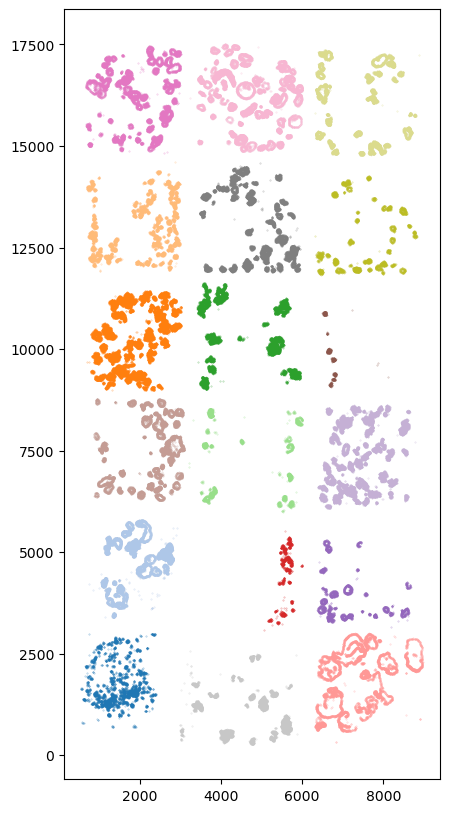

Removing 59063 cells from excluded samples of 18samples
8samples


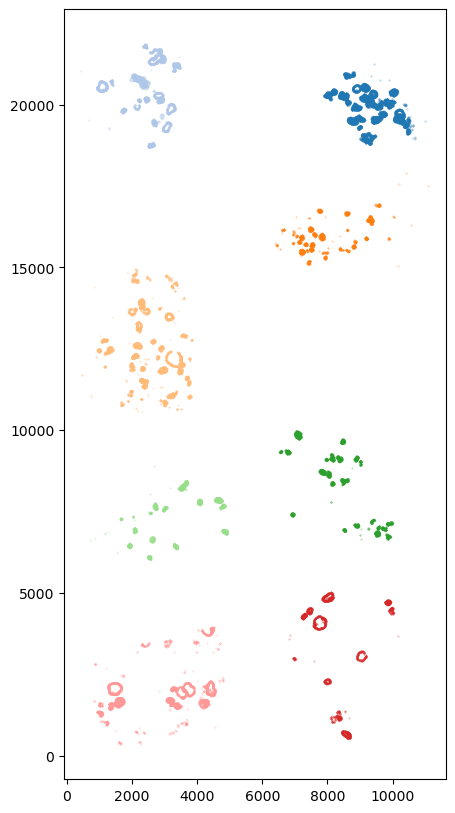

Removing 48 cells from excluded samples of 8samples
9_11_OY6H_middle_and_big


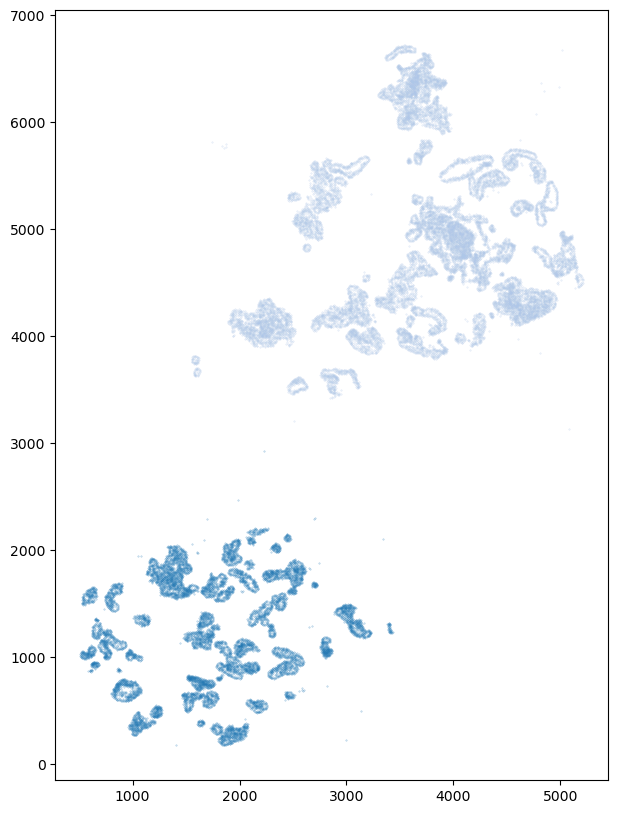

Removing 6 cells from excluded samples of 9_11_OY6H_middle_and_big


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Keeping only run2 samples for CRC_PDO 1GAA and 077I


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Changing condition from CRC_PDO to CRC_PDO_CAF for 18042 cells


...

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 8810 healthy epithelial cells from 1DDI
Relabelling 23297 malignant cells to stromal cells
Filtering out 124276 cells with less than 20 counts


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 28128 cells from bad spatial regions
cohort info:


,donor,sample
CRC,16,16
CRC_PDO,38,38
CRC_PDO_CAF,10,10
CRC_PDO_DEV,6,6


In [ ]:
# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter,
)


# set transcripts=True to load individual transcripts positions)
if correction_method != "raw":
    ads = readwrite.read_count_correction_samples(xenium_paths, [correction_method])
else:
    ads = {}
    ads["raw"] = readwrite.read_xenium_samples(xenium_paths["raw"], anndata=True, pool_mode="thread", max_workers=6)

print(ads['raw'].keys())
# remove 169V sample
# print("Exclude 169V peritoneal sample")
# ads['raw'] = { k:v for k,v in ads['raw'].items() if k[-2] != '169V' }

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# split 18samples and 8samples, keep only samples needed for analysis according to csvs
samples2split = ['18samples','8samples','9_11_OY6H_middle_and_big']
samples2split_dict = {k[-2]: k for k in ads['raw'].keys() if k[-2] in samples2split}
coords_csv_dict = {k: cfg["xenium_metadata_dir"] + f"Regions_coordinates_{k}.csv" for k in samples2split}
readwrite.split_samples_by_coords(ads, samples2split_dict, coords_csv_dict, plot = True)

# concat samples
genes = [v.var_names for k, v in ads[correction_method].items()]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

adata = sc.concat({k: v for k, v in ads[correction_method].items()}, label="dataset_id", join="outer")[
    :, common_genes
].copy()


# create metadata, full cell identifiers
adata.obs[xenium_levels] = pd.DataFrame(adata.obs["dataset_id"].tolist(), index=adata.obs.index, columns=xenium_levels)
adata.obs["correction_method"] = correction_method
adata.obs['cell_id'] = 'proseg-' + adata.obs['cell_id'].astype(str)
adata.obs['full_id'] = adata.obs[['segmentation', 'condition', 'panel', 'donor', 'sample','cell_id']].agg('_'.join, axis=1)
adata.obs["donor_corrected"] = adata.obs["donor_corrected"].fillna(adata.obs["donor"])
adata.obs["sample_corrected"] = adata.obs["sample_corrected"].fillna(adata.obs["sample"])

# all other conditions are Epi cells
adata.obs.loc[adata.obs['condition'] != 'CRC', level] = 'Epi'

# keep only run2 samples for 1GAA and 077I
print('Keeping only run2 samples for CRC_PDO 1GAA and 077I')
run2samples2keep = ['output-XETG00059__0003381__1GAA__20250505__170803','output-XETG00059__0003381__077I__20250505__170803']
adata = adata[
    ~(
        (adata.obs['condition'] == 'CRC_PDO') 
        & (adata.obs['donor'].isin(['077I','1GAA'])) 
        & (~(adata.obs['sample'].isin(run2samples2keep)))
    )
].copy()


# correct condition label for split samples
samples_to_correct_caf = ['1HVQ_big','1HVQ_big_CAFs']
ix_correct_condition_caf = (
    (adata.obs['condition'] == 'CRC_PDO') 
    & (adata.obs['donor_corrected'].isin(samples_to_correct_caf)))
print('Changing condition from CRC_PDO to CRC_PDO_CAF for', samples_to_correct_caf)
adata.obs.loc[ix_correct_condition_caf,'condition'] = 'CRC_PDO_CAF'

samples_to_correct_dev = [
    'OY6H_small','0WJ3_bloc','0WJ3_small','0WJ3_point_3',
    '0WFQ_small','1HVQ_small','1HVQ_middle','0WJ3_big','0WJ3_middle',]
ix_correct_condition_dev = (
    (adata.obs['condition'] == 'CRC_PDO') 
    & (adata.obs['donor_corrected'].isin(samples_to_correct_dev)))
print('Changing condition from CRC_PDO to CRC_PDO_DEV for', samples_to_correct_dev)
adata.obs.loc[ix_correct_condition_dev,'condition'] = 'CRC_PDO_DEV'

# exclude few CAFs that were not washed out
#     adata_sample = adata[adata.obs["donor_corrected"] == "07WM_CAFs"].copy()
#     sc.pp.normalize_total(adata_sample)
#     sc.pp.log1p(adata_sample)
#     sc.pp.neighbors(adata_sample)
#     sc.tl.leiden(adata_sample)
#     sc.tl.umap(adata_sample)
#     sc.pl.umap(adata_sample, color=["leiden","LUM","PDGFRA"])
#     adata_sample.obs[adata_sample.obs['leiden']=='8'].to_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv")
df_cells_to_exclude_07WM_CAFs = pd.read_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv",index_col=0)
adata = adata[
    ~(
        (adata.obs["donor_corrected"]=="07WM_CAFs") 
        & (adata.obs["cell_id"].isin(df_cells_to_exclude_07WM_CAFs["cell_id"]))
    )
].copy()
print("Filtering out",len(df_cells_to_exclude_07WM_CAFs),"CAF cells from 07WM_CAFs")

# exclude bad QC cells creating leiden outlier after data integration
df_cells_to_exclude_leiden_outlier = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_leiden_outlier.csv",index_col=0)
adata = adata[~(adata.obs["full_id"].isin(df_cells_to_exclude_leiden_outlier["full_id"]))].copy()
print("Filtering out",len(df_cells_to_exclude_leiden_outlier),"cells creating outlier leiden cluster after integration")

# exclude healthy epithelial cells from 1DDI
idx_cells_to_exclude_1DDI = pd.read_csv(cfg['xenium_metadata_dir']+"malignant_cells_1DDI_tumor.csv",index_col=0).iloc[:,0].values
adata = adata[~(adata.obs["full_id"].isin(idx_cells_to_exclude_1DDI))].copy()
print("Filtering out",len(idx_cells_to_exclude_1DDI),"healthy epithelial cells from 1DDI")

# relabel epithelial cells with high CAF signature to stromal
idx_cells_to_exclude_malignant = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_from_malignant.csv",index_col=0).iloc[:,0].values
adata.obs.loc[adata.obs['full_id'].isin(idx_cells_to_exclude_malignant),level] = 'Strom'
print("Relabelling",len(idx_cells_to_exclude_malignant),"malignant cells to stromal cells")

# apply QC
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=False)
idx_qc = (adata.obs["total_counts"] > min_n_counts)
print('Filtering out',sum(~idx_qc),f'cells with less than {min_n_counts} counts')
adata = adata[idx_qc].copy()

# apply QC to bad spatial regions
if segmentation == 'proseg_expected':
    df_cells_qc = pd.read_csv(cfg['xenium_metadata_dir']+f"xenium_CRC_PDO_{segmentation}_cells_QC.csv",index_col=0)
    adata = adata[~adata.obs["full_id"].isin(df_cells_qc["full_id"])].copy()
    print('Filtering out',len(df_cells_qc),'cells from bad spatial regions')

print("cohort info:")
df_ = pd.DataFrame(columns=['donor','sample'])
for cond in adata.obs["condition"].unique():
    df_.loc[cond,'donor'] = adata.obs.query(f"condition == '{cond}'")['donor_corrected'].nunique()
    df_.loc[cond,'sample'] = adata.obs.query(f"condition == '{cond}'")['sample_corrected'].nunique()
df_

## integration

In [ ]:
resolutions = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]
do_subsample = False

# subset to malignant cells
adata_malignant = adata[
    (adata.obs[level] == name_malignant)
].copy()
adata_malignant.layers["counts"] = adata_malignant.X.copy()

if do_subsample:
    # subsample (for sanity check, not final results)
    adata_malignant = subsample(adata_malignant, obs_key="sample_corrected", n_obs=10_000)

# preprocess
print('preprocessing')
sc.pp.normalize_total(adata_malignant)
sc.pp.log1p(adata_malignant)
sc.pp.pca(adata_malignant,svd_solver="arpack")

# integrate, cluster, umap
if integration_method == 'bbknn':
    print('bbknn')
    sc.external.pp.bbknn(adata_malignant, batch_key="sample_corrected",approx=True)
    
elif integration_method == 'scvi':
    print('scvi')
    adata_malignant.layers["counts_round"] = adata_malignant.layers['counts'].copy()
    adata_malignant.layers["counts_round"].data = adata_malignant.layers["counts_round"].data.round()

    scvi.settings.seed = SEED
    scvi.settings.num_threads = 1
    scvi.settings.dl_num_workers = 0
    scvi.model.SCVI.setup_anndata(adata_malignant, layer="counts_round", batch_key="sample_corrected")
    model = scvi.model.SCVI(adata_malignant)
    model.train()
    model.save(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/model_{run}.pt")
    adata_malignant.obsm["X_scVI"] = model.get_latent_representation(adata_malignant).astype(np.float32)
    sc.pp.neighbors(adata_malignant, use_rep="X_scVI")

print('leiden')
for r in resolutions:
    sc.tl.leiden(adata_malignant,flavor='igraph',n_iterations=2,resolution=r,key_added=f'leiden_{r}_{integration_method}')
print('umap')
sc.tl.umap(adata_malignant,key_added = f'X_umap_{integration_method}')


if not do_subsample:
    # save
    p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant_{integration_method}_{run}.h5ad")
    p.parent.mkdir(parents=True, exist_ok=True)
    del adata_malignant.obs['dataset_id']
    adata_malignant.obs_names = adata_malignant.obs['full_id']
    adata_malignant.write(p)
    # adata_malignant.obs[['full_id','leiden_1.4','leiden_1.6','leiden_2']].to_csv('../../scratch/cells_passing_QC_leiden_higher_res.csv',index=False)

# subset to shared CRC donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)
adata_shared_donors_malignant = adata_malignant[
    adata_malignant.obs["condition"].isin(["CRC", "CRC_PDO"]) &
    adata_malignant.obs["donor_corrected"].isin(shared_donors)]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


preprocessing


INFO: Seed set to 0
2025-12-07 15:12:36 | [INFO] Seed set to 0


scvi


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_org ...
INFO: GPU available: False, used: False
2025-12-07 15:12:37 | [INFO] GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2025-12-07 15:12:37 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-12-07 15:12:37 | [INFO] HPU available: False, using: 0 HPUs
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SL

Training:   0%|          | 0/15 [00:00<?, ?it/s]

# load saved results

In [7]:
resolutions = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]

p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant_{integration_method}_{run}.h5ad")
adata_malignant = sc.read(p)
# subset to shared CRC donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)
adata_shared_donors_malignant = adata_malignant[
    adata_malignant.obs["condition"].isin(["CRC", "CRC_PDO"]) &
    adata_malignant.obs["donor_corrected"].isin(shared_donors)]

In [8]:
# name leiden clusters (after analysis below)
resolutions = [0.6]
for r in resolutions:
    leiden_key = f'leiden_{r}_{integration_method}'
    
    # name leiden clusters if in dict
    if r in leiden_names:
        adata_malignant.obs[f'{leiden_key}_named'] = adata_malignant.obs[leiden_key].astype(int).replace(leiden_names[r]).astype(str).astype('category')
        adata_shared_donors_malignant.obs[f'{leiden_key}_named'] = adata_shared_donors_malignant.obs[leiden_key].replace(leiden_names[r]).astype(str).astype('category')

adata_malignant.obs.to_parquet(cfg['results_dir']+f'xenium/integration/{correction_method}/{segmentation}/adata_malignant_obs_{integration_method}_{run}.parquet')

# p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant_{integration_method}_{run}.h5ad")
# adata_malignant.write(p)

/tmp/ipykernel_3189399/1680220462.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_shared_donors_malignant.obs[f'{leiden_key}_named'] = adata_shared_donors_malignant.obs[leiden_key].replace(leiden_names[r]).astype(str).astype('category')


## get top DE genes

In [ ]:
adata_malignant = sc.read(path_h5ad)

groupby = programs_key
sc.tl.rank_genes_groups(adata_malignant, groupby=groupby,key_added=f'rank_genes_groups_{groupby}')
df_de_ = sc.get.rank_genes_groups_df(adata_malignant, group=None, key=f'rank_genes_groups_{groupby}')

output_path = Path(cfg['results_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/integration_{top_n}.png')

p = cfg['results_dir'] + ''

# plot results

In [14]:
for r in resolutions:

    print(r)
    leiden_key = f'leiden_{r}_{integration_method}'
    
    # name leiden clusters if in dict
    if r in leiden_names:
        leiden_key +='_named'

    sc.tl.rank_genes_groups(adata_malignant,leiden_key)

    for s in ['dendrogram_'+leiden_key,leiden_key+'_colors']:
        if s in adata_malignant.uns:
            del adata_malignant.uns[s]

    p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant_dotplot_{run}.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        sc.pl.rank_genes_groups_dotplot(
            adata_malignant,
            groupby=leiden_key,
            n_genes=5,
            show = False
        )
        fig = plt.gcf()
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)


        p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant_{run}.csv")
        p.parent.mkdir(parents=True, exist_ok=True)
        df_gene_stats = get_gene_stats(adata_malignant,layer='counts')
        df_de = sc.get.rank_genes_groups_df(adata_malignant, group=None).join(df_gene_stats,on='names')
        df_de.to_csv(p)
    else:
        print('Found file, skipping:',p)


    # umaps
    for n,ad in zip(["adata_malignant", "adata_shared_donors_malignant"],[adata_malignant, adata_shared_donors_malignant]):
        for color in ["condition", "donor_corrected",leiden_key]:
            
            if color == 'donor_corrected' and n == 'adata_malignant':
                pal = None
            else:
                pal = palettes.get(color)

            if integration_method not in color:
                color_name = f'{integration_method}_{color}'
            else:
                color_name = color

            p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/umap_{color_name}_{n}_{run}.png")
            p.parent.mkdir(parents=True, exist_ok=True)
            if not p.exists():

                sc.pl.embedding(
                    ad,
                    f'X_umap_{integration_method}',
                    color=color,
                    show=False,
                    s=.5,
                    # palette=pal,
                )

                fig = plt.gcf()
                fig.savefig(p, dpi=300, bbox_inches="tight")
                plt.close(fig)

            else:
                print('Found file, skipping:',p)


        # umap top 2 DE genes
        p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/umap_top2_DE_{n}_{leiden_key}_{run}.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        if not p.exists():
            top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))

            sc.pl.embedding(
                ad,
                f'X_umap_{integration_method}',
                color=top2['names'].values,
                show=False,
                s=.5,ncols=4,
            )

            fig = plt.gcf()
            fig.savefig(p, dpi=300, bbox_inches="tight")
            plt.close(fig)
        else:
            print('Found file, skipping:',p)

0.6
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/de_leiden_0.6_bbknn_named_adata_malignant_dotplot_12.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/umap_bbknn_condition_adata_malignant_12.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/umap_bbknn_donor_corrected_adata_malignant_12.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/umap_leiden_0.6_bbknn_named_adata_malignant_12.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/umap_top2_DE_adata_malignant_leiden_0.6_bbknn_named_12.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/integration/raw/proseg_expected/umap_top2_DE_adata_shared_donors_malignant_leiden_0.6_bbknn_named_12.png


In [ ]:
for r in resolutions:
    print(r)
    leiden_key = f'leiden_{r}_{integration_method}'
    
    # name leiden clusters if in dict
    if r in leiden_names:
        leiden_key +='_named'

    for n,ad in zip(["adata_malignant", "adata_shared_donors_malignant"],[adata_malignant, adata_shared_donors_malignant]):

        for plot_condition in ["CRC", "CRC_PDO"]: 

            adata_plot = adata_malignant[adata_malignant.obs["condition"] == plot_condition]
            adata_plot.obs[leiden_key] = adata_plot.obs[leiden_key].astype(str)

            df_props = adata_plot.obs.groupby(['donor_corrected','sample_corrected'],observed=True)[leiden_key].value_counts(normalize=True).unstack().reset_index()
            # df_props["full_sample_id"] = df_props[xenium_levels].astype(str).agg(" | ".join, axis=1)
            # df_props = df_props.query(f"segmentation == '{segmentation}'").sort_values("donor")

            # Step 2: Dynamically set the figure size
            num_samples = len(df_props.index)
            fig_height = max(6, num_samples * 0.4)

            # Step 3: Create the figure and axes object
            fig, ax = plt.subplots(figsize=(12, fig_height))

            # Step 4: Plot directly onto the created axes object
            df_props.plot(kind="barh", stacked=True, ax=ax, width=0.8,color=palettes.get(leiden_key))

            # Step 6: Customize the plot
            ax.set_title(f"Proportion of leiden clusters by sample - {segmentation} - {plot_condition}", fontsize=16)
            ax.set_xlabel("Proportion", fontsize=12)
            ax.set_ylabel("Sample ID", fontsize=12)
            ax.set_yticklabels(df_props["donor_corrected"])
            ax.legend(title=leiden_key, bbox_to_anchor=(1.02, 1), loc="upper left")
            ax.set_xlim(0, 1)
            plt.tight_layout()

            p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_umap_{leiden_key}_composition_{plot_condition}_{n}.png")
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=300, bbox_inches="tight")
            plt.close(fig)

            # df_props.to_csv(f'../../scratch/celltype_composition_{segmentation}_{reference}_{level}.csv')

In [ ]:
condition_key="condition"
label_to_transfer="donor_corrected"

for ref_condition, query_condition in [("CRC", "CRC_PDO"), ("CRC_PDO", "CRC")]:
    # USAGE 1: kNN search on PCA embeddings
    predicted_donors_pca = transfer_labels_knn(
        adata=adata_shared_donors_malignant,
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_rep='X_pca' 
    )

    # USAGE 2: bkknn graph
    predicted_donors_graph = transfer_labels_knn(
        adata=adata_shared_donors_malignant, 
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_graph_key="connectivities" 
    )

    # Evaluation 
    true_donors = adata_shared_donors_malignant.obs.loc[adata_shared_donors_malignant.obs[condition_key] == query_condition, label_to_transfer]

    for normalize in ["true", "pred", None]:

        disp=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_pca,
            title="Confusion Matrix from PCA (row normalized)",
            normalize="true", 
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_transfer_confusion_matrix_{integration_method}_{query_condition}_{normalize=}.png",
            show=False
        )

        disp2=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_graph,
            title="Confusion Matrix from bbknn (row normalized)",
            normalize="true",
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_transfer_confusion_matrix_{integration_method}_{query_condition}_{normalize=}.png",
            show=False
        )

## niche analysis by MP for CRC

In [ ]:
import squidpy as sq

cluster_key = f'{leiden_key}_named'

adata.obs_names = adata.obs['full_id']

# add malignant program annotation to full adata
adata.obs[f'{level}_with_programs'] = adata.obs['Level1']
adata.obs.loc[adata_malignant.obs_names,f'{level}_with_programs'] = adata_malignant.obs[cluster_key]
adata.obs[f'{level}_with_programs'] = adata.obs[f'{level}_with_programs'].astype('category')
adata.obs['sample'] = adata.obs['sample'].astype('category')

# enrichment for crc
adata_crc = adata[adata.obs["condition"] == "CRC"]
sq.gr.spatial_neighbors(adata_crc, radius=20, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)
sq.gr.nhood_enrichment(adata_crc, cluster_key=f'{level}_with_programs')
sq.pl.nhood_enrichment(adata_crc, cluster_key=f'{level}_with_programs', method="average", figsize=(5, 5))

## niche analysis by MP for CRC_PDO

In [ ]:
import squidpy as sq

cluster_key = f'{leiden_key}_named'

# enrichment for crc
adata_pdo = adata_malignant[adata_malignant.obs["condition"] == "CRC_PDO"]
sq.gr.spatial_neighbors(adata_pdo, radius=20, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)
sq.gr.nhood_enrichment(adata_pdo, cluster_key=cluster_key)
sq.pl.nhood_enrichment(adata_pdo, cluster_key=cluster_key, method="average", figsize=(5, 5))

## mapping

In [69]:
adata_shared_donors_malignant.obs_names_make_unique()
find_neighbor_same_donor(adata_shared_donors_malignant, source_cond="CRC_PDO", target_cond="CRC", donor_key='donor_corrected')

for donor in adata_shared_donors_malignant.obs["donor_corrected"].unique():
    print(donor)

    # CRC_donor (all cells and malignant only)
    adata_donor = adata[(adata.obs["condition"] == "CRC") & (adata.obs["donor_corrected"] == donor)]
    adata_donor_malignant = adata_donor[(adata_donor.obs[level] == name_malignant)]

    # CRC PDO donor
    adata_shared_donors_malignant_donor = adata_shared_donors_malignant[
          (adata_shared_donors_malignant.obs["condition"] == "CRC") 
        & (adata_shared_donors_malignant.obs["donor"] == donor)].copy()

    # CRC donor matching cells
    adata_shared_donors_malignant_donor_knn = adata_shared_donors_malignant[
        np.array(adata_shared_donors_malignant.obs.query(f"condition == 'CRC_PDO' and donor_corrected == '{donor}'")["neighbor_CRC_index"])
    ].copy()

    # plot
    f, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].scatter(*adata_donor.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
    axs[0].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
    axs[0].set_title("All cell types")
    axs[1].scatter(*adata_donor_malignant.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
    axs[1].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
    axs[1].set_title("Malignant cells")

    plt.suptitle(donor)
    p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_mapping_{integration_method}_{donor}.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    f.savefig(p, dpi=300, bbox_inches="tight")
    plt.close(f)
    # plt.show()

    break

Searching for neighbors for cells in 'CRC_PDO' within 'CRC'.
Found 15 unique donors to process.
Processing donor 15/15: OUC1
Finished processing all donors.
Successfully added columns: 'neighbor_CRC_obs_name', 'neighbor_CRC_index', 'neighbor_CRC_dist' to adata.obs.
1EGQ


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
import scipy.cluster.hierarchy as sch

donors = adata_shared_donors_malignant.obs['donor_corrected'].unique()

records = []

# 1. Iterate and Compute Stats per Donor
for donor in donors:
    obs_crc_pdo_donor = adata_shared_donors_malignant.obs.query(
        f"condition == 'CRC_PDO' and donor_corrected == '{donor}'"
    )
    
    if len(obs_crc_pdo_donor) < 1000: 
        print(f"Skipping {donor}: not enough cells.")
        continue

    # Get paired indices
    ad_donor_1nn_crc = adata_shared_donors_malignant[obs_crc_pdo_donor["neighbor_CRC_obs_name"]]
    ad_donor_crc_pdo = adata_shared_donors_malignant[obs_crc_pdo_donor.index]
    
    # Combined view for filtering and % calculation
    ad_donor_to_correlate = adata_shared_donors_malignant[
        obs_crc_pdo_donor.index.tolist() + obs_crc_pdo_donor["neighbor_CRC_obs_name"].tolist()
    ].copy()

    # Filter genes: >100 cells with counts >= 1 (Adjust threshold as needed)
    n_cells_threshold = 1000
    cells_expressing = (ad_donor_to_correlate.X > 0).sum(0)
    genes_mask = np.array(cells_expressing > n_cells_threshold).ravel()
    genes2corr = ad_donor_crc_pdo.var_names[genes_mask]
    
    # Convert to DF for correlation
    df_crc_pdo = ad_donor_crc_pdo[:, genes2corr].to_df().reset_index(drop=True)
    df_1nn_crc = ad_donor_1nn_crc[:, genes2corr].to_df().reset_index(drop=True)
    
    # A. Calculate Correlation (The Color)
    correlations = df_crc_pdo.corrwith(df_1nn_crc, method='spearman')
    
    # B. Calculate % Expressed (The Size)
    # We define this as % of cells in the PAIR (PDO+1NN) that express the gene
    # (Alternatively, you could calculate this just on PDOs if preferred)
    n_cells_total = ad_donor_to_correlate.shape[0]
    # We already computed sum above, just grab subset and divide
    pct_expressed = np.array(cells_expressing)[0, genes_mask] / n_cells_total

    # Store Data
    for gene, corr, pct in zip(genes2corr, correlations, pct_expressed):
        records.append({
            'Donor': donor,
            'Gene': gene,
            'Correlation': corr,
            'Pct_Expressed': pct
        })

# 2. Create Long DataFrame
df_long = pd.DataFrame(records)

# 3. Filter for Intersection of Genes
# (Like dropna() in clustermap, we only want genes present in ALL processed donors to make a nice grid)
donors_processed = df_long['Donor'].unique()
genes_per_donor = df_long.groupby('Gene')['Donor'].nunique()
common_genes = genes_per_donor[genes_per_donor == len(donors_processed)].index

df_plot = df_long[df_long['Gene'].isin(common_genes)].copy()

print(f"Plotting {len(common_genes)} genes across {len(donors_processed)} donors.")

# ---------------------------------------------------------
# 4. Clustering to Order the Axes (Matrix Logic)
# ---------------------------------------------------------
# Pivot to Wide format (Genes x Donors) just for clustering
df_pivot = df_plot.pivot(index='Gene', columns='Donor', values='Correlation')

# Cluster Genes (Rows)
row_linkage = sch.linkage(df_pivot, method='average', metric='euclidean')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
gene_order = df_pivot.index[row_dendro['leaves']]

# Cluster Donors (Columns)
col_linkage = sch.linkage(df_pivot.T, method='average', metric='euclidean')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
donor_order = df_pivot.columns[col_dendro['leaves']]

# Apply order to DataFrame (Convert to Categorical)
df_plot['Gene'] = pd.Categorical(df_plot['Gene'], categories=gene_order, ordered=True)
df_plot['Donor'] = pd.Categorical(df_plot['Donor'], categories=donor_order, ordered=True)

# ---------------------------------------------------------
# 5. Plotting the Dotplot
# ---------------------------------------------------------
plt.figure(figsize=(len(donors_processed) * 0.8 + 2, len(common_genes) * 0.3 + 2))
sns.set_style("whitegrid")

# Create Scatterplot
g = sns.scatterplot(
    data=df_plot,
    x='Donor', 
    y='Gene',
    hue='Correlation', 
    size='Pct_Expressed',
    palette='bwr',       # Blue-White-Red
    hue_norm=(-1, 1),    # Center color map at 0
    sizes=(20, 250),     # Min and Max dot size
    edgecolor='black',   # Adds a ring to dots to make them pop against white
    linewidth=0.5
)

# Customizing the Layout
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('PDO vs 1NN Similarity\n(Color=Correlation, Size=% Expressed)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.margins(y=0.01)

# Add a colorbar explicitly if you want a gradient bar instead of discrete legend points
norm = plt.Normalize(-1, 1)
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.15)
cbar.set_label('Spearman Correlation', rotation=270, labelpad=15)
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left', borderaxespad=0.)

plt.show()

KeyError: 'neighbor_CRC_obs_name'

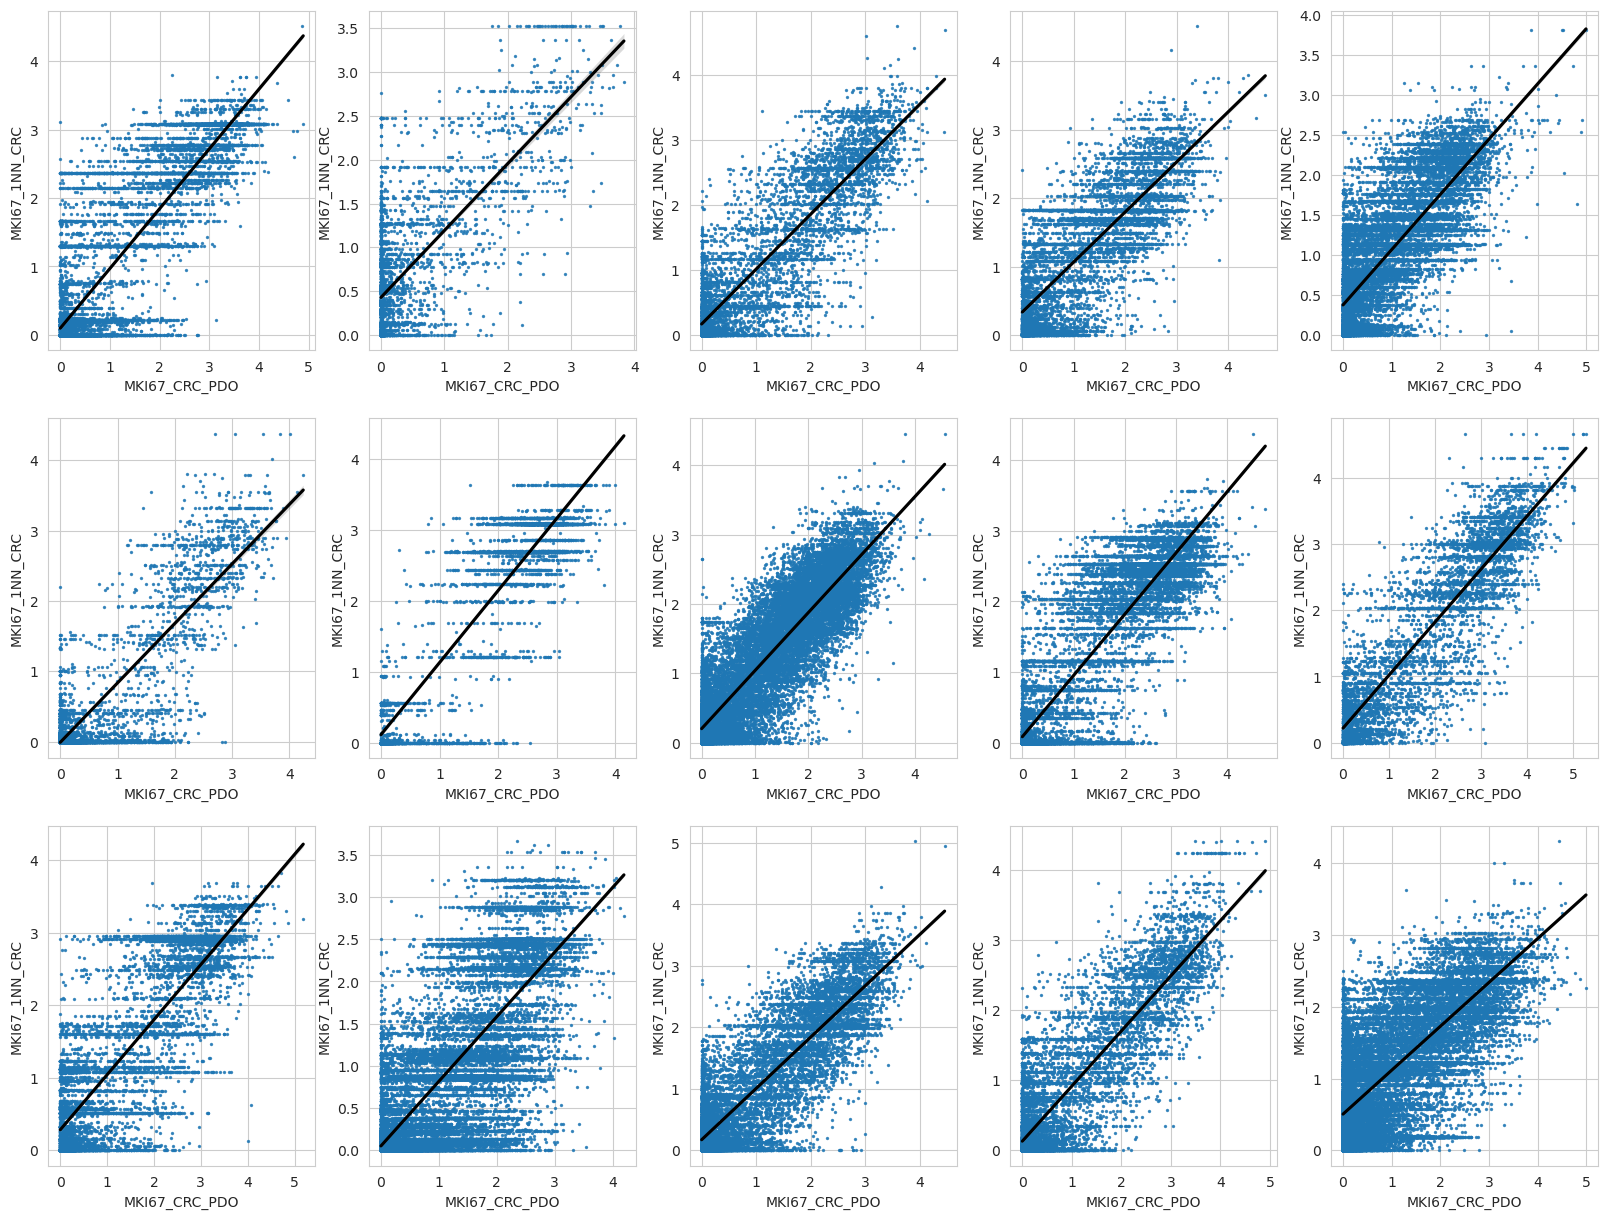

In [225]:
f,axs = plt.subplots(3,5,figsize=(20,15))
axs = axs.flat
gene = "MKI67"
for donor in donors:
    obs_crc_pdo_donor = adata_shared_donors_malignant.obs.query(
        f"condition == 'CRC_PDO' and donor_corrected == '{donor}'"
    )
    
    if len(obs_crc_pdo_donor) < 1000: 
        print(f"Skipping {donor}: not enough cells.")
        continue

    # Get paired indices
    ad_donor_1nn_crc = adata_shared_donors_malignant[obs_crc_pdo_donor["neighbor_CRC_obs_name"]]
    ad_donor_crc_pdo = adata_shared_donors_malignant[obs_crc_pdo_donor.index]


    df_plot = (
        ad_donor_crc_pdo.to_df().reset_index(drop=True).join(
            ad_donor_1nn_crc.to_df().reset_index(drop=True), 
        lsuffix="_CRC_PDO", rsuffix="_1NN_CRC")
    )

    ax = next(axs)
    sns.regplot(df_plot,x=f"{gene}_CRC_PDO",y=f"{gene}_1NN_CRC",ax=ax,scatter_kws=dict(s=2),line_kws={"color": "black"})
    for line in ax.lines:
        line.set_zorder(10)

plt.show()

# bbknn chromium / CRC_PDO

In [ ]:
# load chromium, subset xneium to malignant CRC
ad_sc = sc.read_10x_h5(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/RNA_counts.h5')
ad_sc.obs = ad_sc.obs.join(pd.read_parquet(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/metadata.parquet').set_index('cell_id'))
ad_sc.obs['patient'] = ad_sc.obs['patient'].replace({'14VS': '14V5'})
ad_sc.obs['donor_corrected'] = ad_sc.obs['patient']
ad_sc.obs['condition'] = 'chromium'
ad_sc.layers['counts'] = ad_sc.X

adata_malignant_PDO = adata_malignant[adata_malignant.obs["condition"] == "CRC_PDO"].copy()
sc.pp.subsample(adata_malignant_PDO, n_obs=len(ad_sc), copy=False)

# concat modalities
genes = [adata_malignant_PDO.var_names, ad_sc.var_names]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

ad_sc_crc = sc.concat({'chromium':ad_sc, 'xenium':adata_malignant_PDO}, label="modality", join="outer")[
    :, common_genes
].copy()


# subset to common donors
u = ad_sc.obs['donor_corrected'].unique()
ad_sc_pdo_shared_donors = ad_sc_crc[ad_sc_crc.obs['donor_corrected'].isin(u)]
# ad_sc_pdo_shared_donors.obs[['condition','donor_corrected']].drop_duplicates()

# preprocess
sc.pp.normalize_total(ad_sc_pdo_shared_donors)
sc.pp.log1p(ad_sc_pdo_shared_donors)
sc.pp.pca(ad_sc_pdo_shared_donors)

if integration_method == 'bbknn':
    # integrate, cluster, umap
    sc.external.pp.bbknn(ad_sc_pdo_shared_donors, batch_key="condition")
else:
    raise ValueError('only bbknn implemented')
# sc.tl.leiden(ad_sc_crc,flavor='igraph',n_iterations=2,resolution=.6)
sc.tl.umap(ad_sc_pdo_shared_donors)


# save
p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/ad_sc_pdo_shared_donors_{integration_method}.h5ad")
p.parent.mkdir(parents=True, exist_ok=True)
ad_sc_pdo_shared_donors.write(p)

In [ ]:
for n,ad in zip(["ad_sc_pdo_shared_donors"],[ad_sc_pdo_shared_donors]):
    for color in ["condition", "donor_corrected"]:
        sc.pl.umap(
            ad,
            color=color,
            show=False,
        )

        fig = plt.gcf()

        p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/umap_{integration_method}_{color}_{n}.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

In [ ]:
condition_key="condition"
label_to_transfer="donor_corrected"

for ref_condition, query_condition in [("CRC_PDO", "chromium"), ("chromium", "CRC_PDO")]:
    # USAGE 1: kNN search on PCA embeddings
    predicted_donors_pca = transfer_labels_knn(
        adata=ad_sc_pdo_shared_donors,
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_rep='X_pca' 
    )

    # USAGE 2: bkknn graph
    predicted_donors_graph = transfer_labels_knn(
        adata=ad_sc_pdo_shared_donors, 
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_graph_key="connectivities" 
    )

    # Evaluation 
    true_donors = ad_sc_pdo_shared_donors.obs.loc[ad_sc_pdo_shared_donors.obs[condition_key].str.contains(query_condition), label_to_transfer]

    for normalize in ["true", "pred", None]:

        disp=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_pca,
            title=f"Confusion Matrix from PCA ({normalize} normalized)",
            normalize="true", 
            text_kw={"fontsize": 5},
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_chromium_transfer_confusion_matrix_{integration_method}_{query_condition}_{normalize=}.png",
            show=False
        )

        disp2=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_graph,
            title=f"Confusion Matrix from bbknn ({normalize} normalized)",
            normalize="true",
            text_kw={"fontsize": 5},
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_chromium_transfer_confusion_matrix_{integration_method}_{query_condition}_{normalize=}.png",
            show=False
        )

## CoDa kNN / not kNN

In [ ]:
import coda
donor = 'OUC1'

adata_donor = adata[(adata.obs["condition"] == "CRC") & (adata.obs["donor"] == donor)]
adata_donor_malignant = adata_donor[(adata_donor.obs[level] == name_malignant)]

adata_shared_donors_malignant_donor = adata_shared_donors_malignant[(adata_shared_donors_malignant.obs["condition"] == "CRC") & (adata_shared_donors_malignant.obs["donor"] == donor)].copy()
adata_shared_donors_malignant_donor_knn = adata_shared_donors_malignant[
    np.array(adata_shared_donors_malignant.obs.query(f"condition == 'CRC_PDO' and donor == '{donor}'")["neighbor_CRC_index"])
].copy()
adata_shared_donors_malignant_donor_knn.obs_names = adata_shared_donors_malignant_donor_knn.obs_names.str[:-2]
adata_shared_donors_malignant_donor_not_knn = adata_shared_donors_malignant_donor[adata_shared_donors_malignant_donor.obs_names.difference(adata_shared_donors_malignant_donor_knn.obs_names)].copy()


# f, axs = plt.subplots(1, 2, figsize=(12, 6))
# axs[0].scatter(*adata_donor.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
# axs[0].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
# axs[0].set_title("All cell types")
# axs[1].scatter(*adata_donor_malignant.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
# axs[1].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
# axs[1].set_title("Malignant cells")
# plt.suptitle(donor)
# plt.show()

df_plot = pd.concat((pd.DataFrame(adata_donor.obsm['spatial'],index=adata_donor.obs_names,columns=['x','y']),adata_donor.obs[[level]]),axis=1)
plt.figure(figsize=(10,10))
ax = sns.scatterplot(data=df_plot, x="x", y="y", s=3, alpha=0.3, hue=level)
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_markersize(10.0) 
ax.legend(handles, labels)

In [ ]:
sq.gr.spatial_neighbors(adata_donor, radius=10, spatial_key='spatial',coord_type='generic',set_diag=True)

knnidx,knndist = coda.sparse_to_knn(adata_donor.obsp['spatial_connectivities'])
adata_ilr = coda.get_ilr(adata_donor, knnidx=knnidx, label_key=level)
adata_ilr_knn = adata_ilr[adata_ilr.obs_names.isin(adata_shared_donors_malignant_donor_knn.obs_names)]
adata_ilr_not_knn = adata_ilr[adata_ilr.obs_names.isin(adata_shared_donors_malignant_donor_not_knn.obs_names)]

for adata_plot in [adata_ilr_knn, adata_ilr_not_knn]: 

    # sort by PC1 and normalize to 1
    PC1 = adata_plot.obsm['X_ilr_pca'][:,0]
    df_plot = pd.DataFrame(adata_plot.obsm['X_composition'],columns=adata_plot.uns['X_knnlabels_columns'])
    df_plot = df_plot.iloc[np.argsort(PC1)].T
    df_plot.columns = np.arange(df_plot.shape[1])


    f, axs = plt.subplots(2,1,figsize=(30,10))

    ax = axs[0]
    ax = sns.heatmap(data=df_plot,ax=ax)
    ax.set_xticks([])
    ax.set_yticklabels(df_plot.index, rotation = 0)
    ax.set_ylabel('Cell types')
    ax.set_xlabel('Sorted ILR PC1 index')


    ax = axs[1]
    ax.stackplot(df_plot.columns, *df_plot.values, labels=df_plot.index)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel('% of neighboring cells')
    ax.set_xlabel('ILR PC1')
    ax.legend(
        title='Cell Type', 
        loc='center left', 
        bbox_to_anchor=(1.0, 0.5)
    )
    ax.margins(x=0, y=0)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()